# Load dataset

In [1]:
from temporal.load_data_temp import load_temporal_images

In [2]:
base_path_temporal = "data/Fotos_temporales/"
temporal_dataset = load_temporal_images(base_path_temporal)

## Check dataset

In [3]:
for time_label, groups in temporal_dataset.items():
    for group, imgs in groups.items():
        print(f"{time_label:>4} | {group:>2} | {len(imgs)} imágenes")

 0HS | N1 | 4 imágenes
 0HS | N2 | 4 imágenes
 0HS | N3 | 4 imágenes
 0HS | N4 | 4 imágenes
24HS | N1 | 4 imágenes
24HS | N2 | 4 imágenes
24HS | N3 | 4 imágenes
24HS | N4 | 4 imágenes
48HS | N1 | 4 imágenes
48HS | N2 | 4 imágenes
48HS | N3 | 4 imágenes
48HS | N4 | 4 imágenes
72HS | N1 | 4 imágenes
72HS | N2 | 4 imágenes
72HS | N3 | 4 imágenes
72HS | N4 | 4 imágenes


In [4]:
for time_label, groups in temporal_dataset.items():
    for group, imgs in groups.items():
        if len(imgs) > 0:
            print(f"{time_label} - {group}: {imgs[0]['image'].shape}")

0HS - N1: (1536, 2040, 3)
0HS - N2: (1536, 2040, 3)
0HS - N3: (1536, 2040, 3)
0HS - N4: (1536, 2040, 3)
24HS - N1: (1536, 2040, 3)
24HS - N2: (1536, 2040, 3)
24HS - N3: (1536, 2040, 3)
24HS - N4: (1536, 2040, 3)
48HS - N1: (1536, 2040, 3)
48HS - N2: (1536, 2040, 3)
48HS - N3: (1536, 2040, 3)
48HS - N4: (1536, 2040, 3)
72HS - N1: (1536, 2040, 3)
72HS - N2: (1536, 2040, 3)
72HS - N3: (1536, 2040, 3)
72HS - N4: (1536, 2040, 3)


# Preprocesamiento: extraer canal verde y crear su dataset normalizado

In [6]:
from src.preprocessing import extract_green_channel, normalize_dataset

In [7]:
temporal_green = extract_green_channel(temporal_dataset)
temporal_green_norm = normalize_dataset(temporal_green, robust=True)

## Check

In [8]:
first_time = list(temporal_green_norm.keys())[0]
first_group = list(temporal_green_norm[first_time].keys())[0]

print(temporal_dataset[first_time][first_group][0].keys())
print(temporal_green[first_time][first_group][0].keys())
print(temporal_green_norm[first_time][first_group][0].keys())

dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])
dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])
dict_keys(['name', 'image', 'group', 'time_label', 'time_h'])


# Extract features

In [ ]:
import importlib
from temporal import pipeline_temp
importlib.reload(pipeline_temp)
from temporal.pipeline_temp import build_temporal_feature_dataset

In [17]:
df_temporal = build_temporal_feature_dataset(
    temporal_green_norm,
    q=80,
    variant="closing_r3",
    prune_iters=5
)

print(df_temporal.head())
print(df_temporal.shape)
print(df_temporal.groupby(["time_label", "group"]).size())

df_temporal.to_csv("features_dataset_temporal.csv", index=False)

   mask_area  fill_ratio  n_components  largest_component_area  \
0     621371    0.198303           175                105392.0   
1     626930    0.200077           177                175268.0   
2     615747    0.196508           215                126299.0   
3     611678    0.195210           238                 72312.0   
4     622016    0.198509           199                136781.0   

   largest_component_ratio  mean_component_area  std_component_area  \
0                 0.169612          3550.691429        12278.464942   
1                 0.279566          3541.977401        13970.684168   
2                 0.205115          2863.939535        10678.551265   
3                 0.118219          2570.075630         7194.847730   
4                 0.219899          3125.708543        12824.703776   

   median_component_area  skeleton_length  n_endpoints  ...  \
0                  587.0            33655          928  ...   
1                  606.0            34557         

## Plot features finales de binario vs tiempo

In [15]:
importlib.reload(pipeline_temp)
from temporal.pipeline_temp import plot_temporal_feature_boxplots

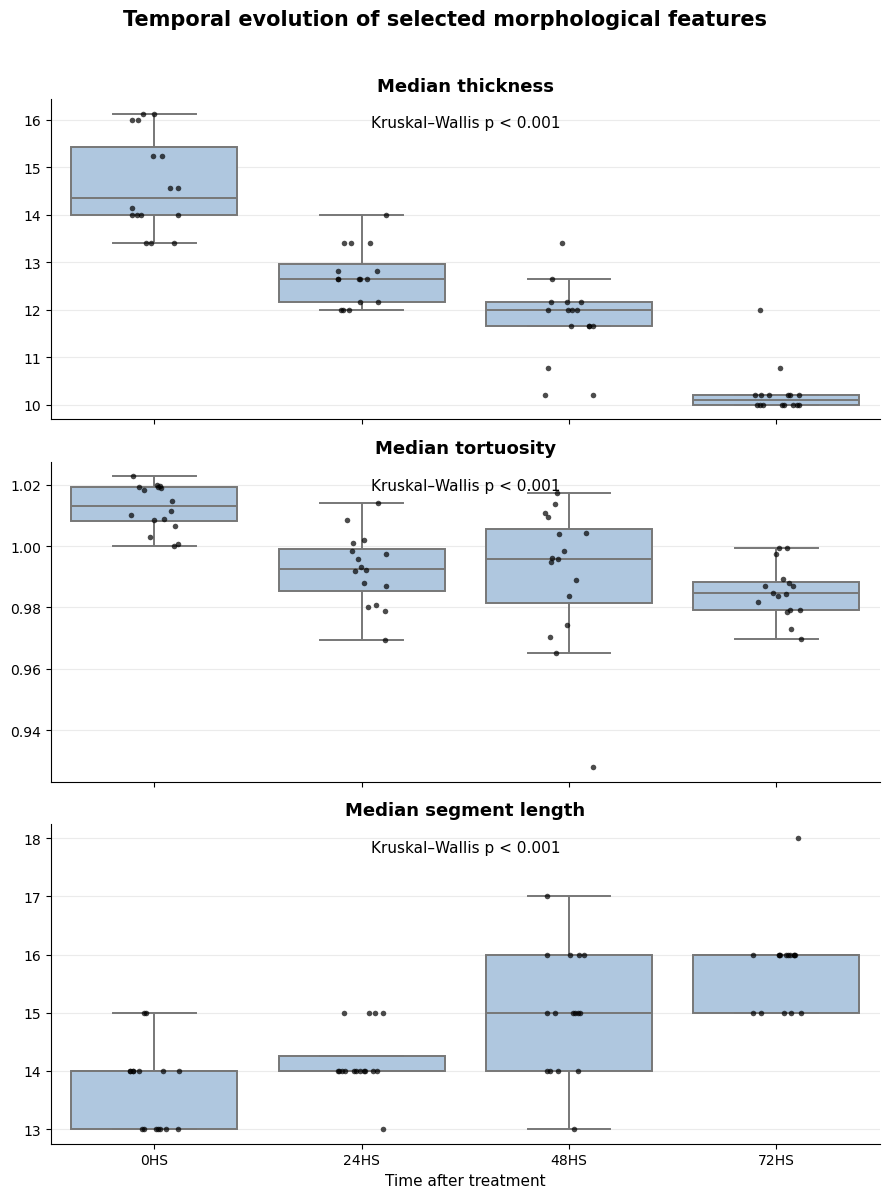

Saved → temporal_feature_boxplots.png


In [16]:
plot_temporal_feature_boxplots(df_temporal)

## Rank features

In [18]:
import importlib
import temporal.feature_selection_temporal as fst

importlib.reload(fst)

<module 'temporal.feature_selection_temporal' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/feature_selection_temporal.py'>

In [19]:
results_temporal = fst.rank_temporal_features(df_temporal)
fst.print_temporal_report(results_temporal, top_n=15)

  TEMPORAL FEATURE RANKING REPORT (top 15)
 rank               feature importance_tier  composite_score_norm  spearman_rho  sig_spearman  sig_kruskal      trend
    1      median_thickness          🔴 HIGH            100.000000     -0.918096          True         True decreasing
    2        branch_density          🔴 HIGH             99.588681      0.910867          True         True increasing
    3       skeleton_length          🔴 HIGH             99.588681      0.910867          True         True increasing
    4        mean_thickness          🔴 HIGH             94.631684     -0.865475          True         True decreasing
    5 median_segment_length          🔴 HIGH             79.742556      0.747403          True         True increasing
    6   mean_segment_length          🔴 HIGH             77.588503      0.733082          True         True increasing
    7         std_thickness          🔴 HIGH             73.790493     -0.714168          True         True decreasing
    8        

In [47]:
results_temporal.to_csv("temporal_feature_ranking_results.csv", index=False)

## Prunning by correlation with HIGH features

In [20]:
high_temporal = results_temporal[results_temporal["importance_tier"] == "🔴 HIGH"]["feature"].tolist()
print(high_temporal)

['median_thickness', 'branch_density', 'skeleton_length', 'mean_thickness', 'median_segment_length', 'mean_segment_length', 'std_thickness']


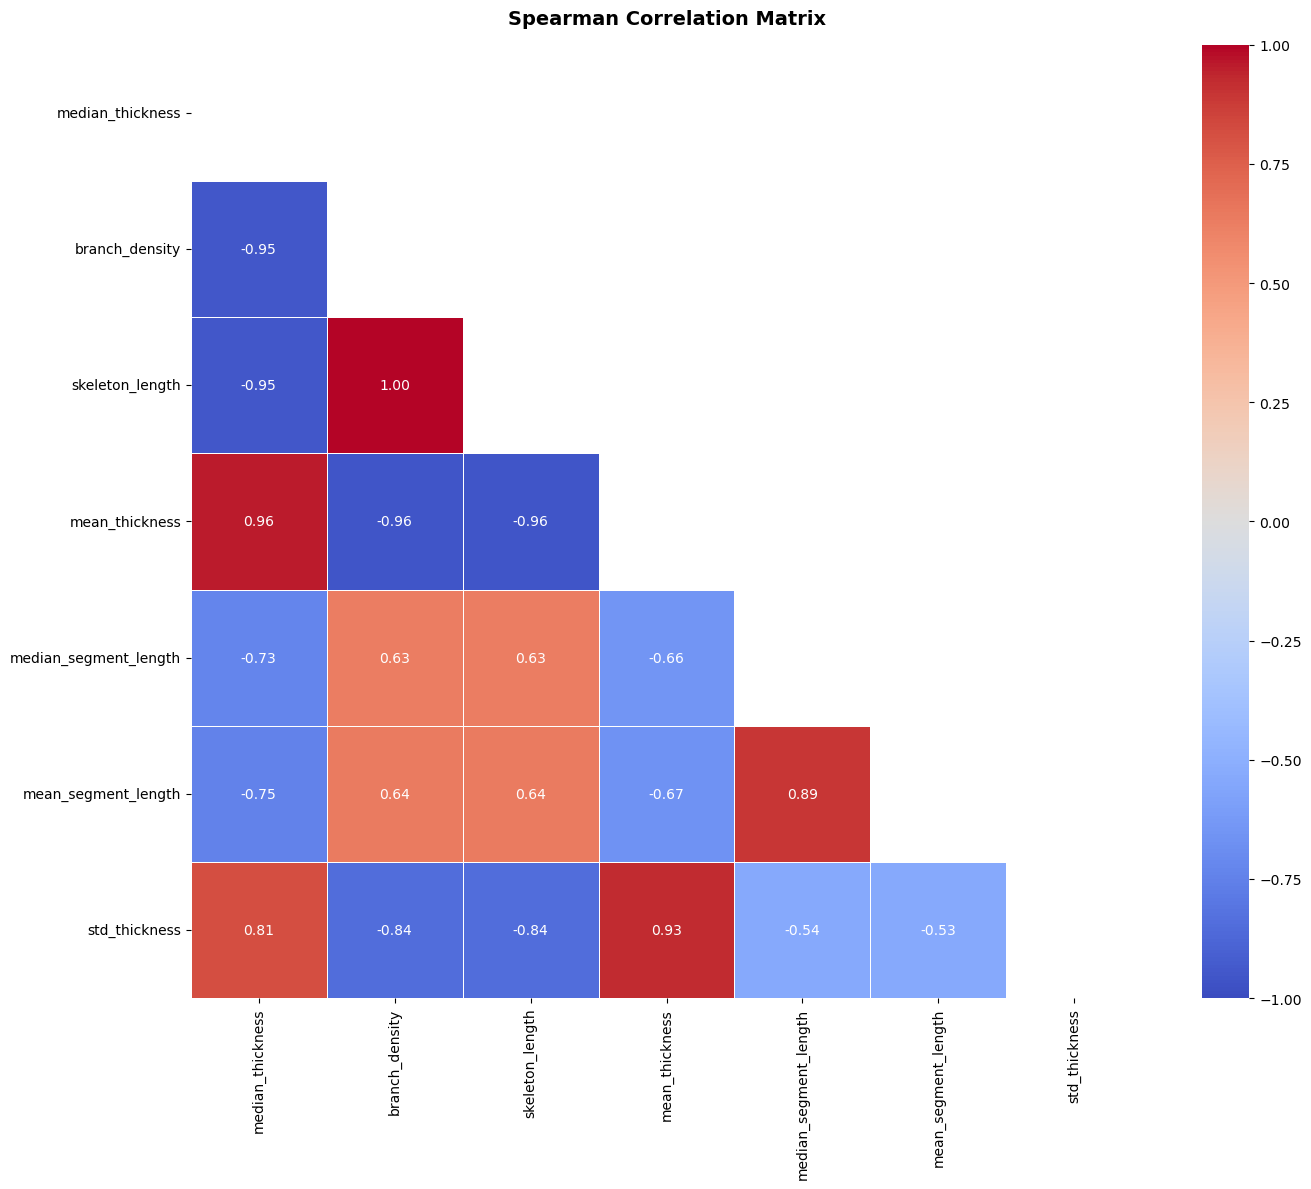

[Step 2] Correlation matrix saved → correlation_matrix.png

[Step 2] Pairs with |r| > 0.85:
            feature_a           feature_b  spearman_r  score_a  score_b                  kept             dropped
       branch_density     skeleton_length      1.0000    99.59    99.59        branch_density     skeleton_length
       branch_density      mean_thickness     -0.9596    99.59    94.63        branch_density      mean_thickness
      skeleton_length      mean_thickness     -0.9596    99.59    94.63       skeleton_length      mean_thickness
     median_thickness      mean_thickness      0.9590   100.00    94.63      median_thickness      mean_thickness
     median_thickness      branch_density     -0.9502   100.00    99.59      median_thickness      branch_density
     median_thickness     skeleton_length     -0.9502   100.00    99.59      median_thickness     skeleton_length
       mean_thickness       std_thickness      0.9257    94.63    73.79        mean_thickness       std_thickn

In [21]:
import feature_selection_pipeline as fsp

pruned_temporal, corr_pairs_temporal = fsp.prune_correlated_features(
    df_temporal,
    high_temporal,
    results_temporal.rename(columns={"composite_score_norm": "composite_score_norm"})
)

print(pruned_temporal)
print(corr_pairs_temporal)

### Pesos derivados de rho

In [48]:
import importlib
import temporal.pipeline_temp

importlib.reload(temporal.pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [49]:
weights = pipeline_temp.get_temporal_feature_weights(results_temporal)

print("Rho exactos usados:")
print(
    results_temporal.loc[
        results_temporal["feature"].isin(["median_thickness", "median_segment_length"]),
        ["feature", "spearman_rho", "p_spearman", "p_spearman_corrected", "trend"]
    ]
)

print("\nPesos derivados de rho:")
for k, v in weights.items():
    print(f"{k}: {v:.4f}")

Rho exactos usados:
                 feature  spearman_rho    p_spearman  p_spearman_corrected  \
0       median_thickness     -0.918096  1.321969e-26          3.701513e-25   
4  median_segment_length      0.747403  1.302236e-12          7.292524e-12   

        trend  
0  decreasing  
4  increasing  

Pesos derivados de rho:
median_thickness: 0.5512
median_segment_length: 0.4488


## Features selected in temporal space

In [23]:
import importlib
import temporal.feature_selection_temporal as fst

importlib.reload(fst)

from temporal.feature_selection_temporal import plot_temporal_feature_space

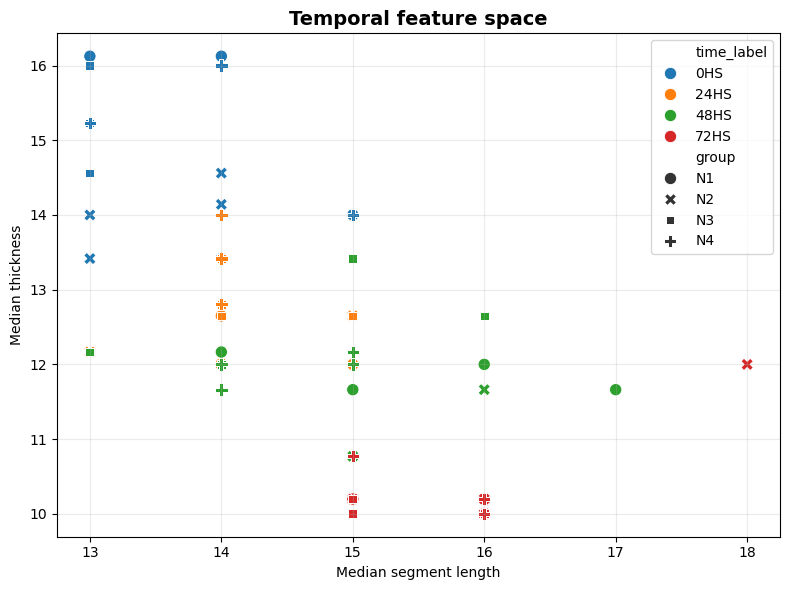

Saved → temporal_feature_space.png


In [24]:
plot_temporal_feature_space(df_temporal)

## Crear el score absoluto (fallback)

In [59]:
df_temporal_group = (
    df_temporal
    .groupby(["group", "time_label", "time_h"], as_index=False)
    .agg({
        "median_thickness": "mean",
        "median_segment_length": "mean"
    })
    .sort_values(["group", "time_h"])
    .reset_index(drop=True)
)

print(df_temporal_group)
print(df_temporal_group.shape)

   group time_label  time_h  median_thickness  median_segment_length
0     N1        0HS       0         14.916360                  14.00
1     N1       24HS      24         12.203659                  14.25
2     N1       48HS      48         11.872333                  15.50
3     N1       72HS      72         10.099020                  15.75
4     N2        0HS       0         14.029691                  13.50
5     N2       24HS      24         12.365937                  14.25
6     N2       48HS      48         10.707078                  15.50
7     N2       72HS      72         10.599020                  16.25
8     N3        0HS       0         14.802043                  13.25
9     N3       24HS      24         12.880219                  14.25
10    N3       48HS      48         12.557761                  14.50
11    N3       72HS      72         10.049510                  15.50
12    N4        0HS       0         14.807887                  14.00
13    N4       24HS      24       

In [60]:
anchors_group = pipeline_temp.get_population_anchors(
    df_temporal_group,
    thickness_col="median_thickness",
    segment_col="median_segment_length"
)

print(anchors_group)

{'ctrl_ref': {'median_thickness': 14.638995137031191, 'median_segment_length': 13.6875}, 'inflam_ref': {'median_thickness': 10.247410236086402, 'median_segment_length': 15.8125}}


In [61]:
from scipy.stats import spearmanr

rho_thickness, p_thickness = spearmanr(
    df_temporal_group["time_h"],
    df_temporal_group["median_thickness"]
)

rho_segment, p_segment = spearmanr(
    df_temporal_group["time_h"],
    df_temporal_group["median_segment_length"]
)

print("Rho group-level:")
print("median_thickness:", rho_thickness, "p=", p_thickness)
print("median_segment_length:", rho_segment, "p=", p_segment)

Rho group-level:
median_thickness: -0.9458889376416987 p= 3.154794598281738e-08
median_segment_length: 0.9557790087219502 p= 7.886241272347204e-09


In [62]:
abs_rho_thickness = abs(rho_thickness)
abs_rho_segment = abs(rho_segment)

w_t_group = abs_rho_thickness / (abs_rho_thickness + abs_rho_segment)
w_s_group = abs_rho_segment / (abs_rho_thickness + abs_rho_segment)

print("Pesos group-level:")
print("median_thickness:", w_t_group)
print("median_segment_length:", w_s_group)

Pesos group-level:
median_thickness: 0.49739963249126556
median_segment_length: 0.5026003675087344


In [63]:
ctrl_t_g = anchors_group["ctrl_ref"]["median_thickness"]
ctrl_s_g = anchors_group["ctrl_ref"]["median_segment_length"]
inflam_t_g = anchors_group["inflam_ref"]["median_thickness"]
inflam_s_g = anchors_group["inflam_ref"]["median_segment_length"]

df_temporal_group_scored = df_temporal_group.copy()

df_temporal_group_scored["absolute_inflammatory_score"] = df_temporal_group_scored.apply(
    lambda row: pipeline_temp._compute_absolute_inflammatory_score(
        thickness=row["median_thickness"],
        segment_length=row["median_segment_length"],
        ctrl_thickness=ctrl_t_g,
        inflam_thickness=inflam_t_g,
        ctrl_segment=ctrl_s_g,
        inflam_segment=inflam_s_g,
        w_thickness=w_t_group,
        w_segment=w_s_group
    ),
    axis=1
)

print(df_temporal_group_scored)

   group time_label  time_h  median_thickness  median_segment_length  \
0     N1        0HS       0         14.916360                  14.00   
1     N1       24HS      24         12.203659                  14.25   
2     N1       48HS      48         11.872333                  15.50   
3     N1       72HS      72         10.099020                  15.75   
4     N2        0HS       0         14.029691                  13.50   
5     N2       24HS      24         12.365937                  14.25   
6     N2       48HS      48         10.707078                  15.50   
7     N2       72HS      72         10.599020                  16.25   
8     N3        0HS       0         14.802043                  13.25   
9     N3       24HS      24         12.880219                  14.25   
10    N3       48HS      48         12.557761                  14.50   
11    N3       72HS      72         10.049510                  15.50   
12    N4        0HS       0         14.807887                  1

In [64]:
summary_group_abs = (
    df_temporal_group_scored
    .groupby("time_label")["absolute_inflammatory_score"]
    .agg(["mean", "std", "median", "min", "max"])
    .reindex(["0HS", "24HS", "48HS", "72HS"])
)

print(summary_group_abs)

                    mean        std     median        min         max
time_label                                                           
0HS        -4.662937e-15   8.223084   3.358044 -12.194372    5.478284
24HS        3.361863e+01   8.829712  36.136806  21.313675   40.887229
48HS        6.349805e+01  20.882033  61.900059  42.789546   87.402531
72HS        1.000000e+02   4.798884  99.392232  94.850278  106.365258


In [65]:
threshold_info_group = pipeline_temp.get_category_thresholds_from_data(
    df_temporal_group_scored,
    score_col="absolute_inflammatory_score"
)

print("Means by time (group-level score):")
print(threshold_info_group["means_by_time"])

print("\nThresholds group-level:")
print(threshold_info_group["thresholds"])

Means by time (group-level score):
{'0HS': -4.6629367034256575e-15, '24HS': 33.618628755165204, '48HS': 63.49804872668351, '72HS': 100.0}

Thresholds group-level:
[16.8093143775826, 48.558338740924356, 81.74902436334176]


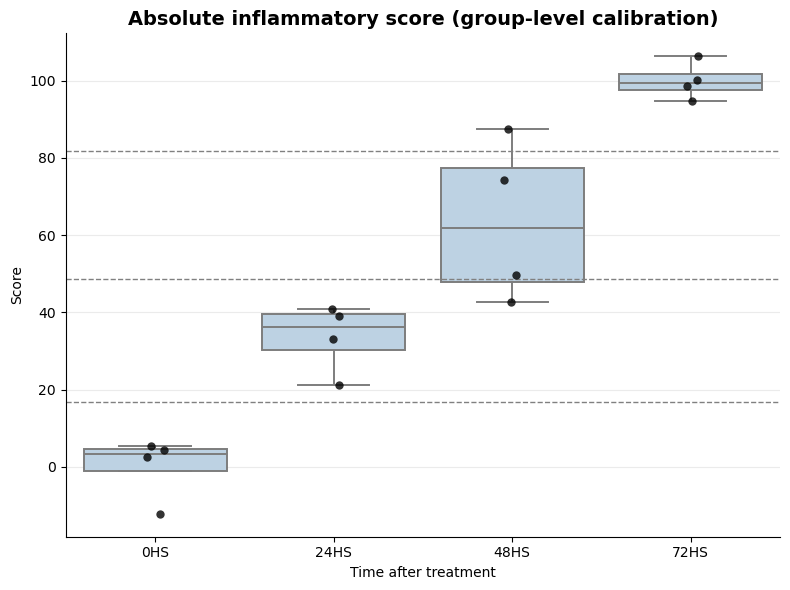

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

thresholds_group = threshold_info_group["thresholds"]

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_temporal_group_scored,
    x="time_label",
    y="absolute_inflammatory_score",
    order=["0HS", "24HS", "48HS", "72HS"],
    color="#B7D3E9",
    fliersize=0,
    linewidth=1.4
)

sns.stripplot(
    data=df_temporal_group_scored,
    x="time_label",
    y="absolute_inflammatory_score",
    order=["0HS", "24HS", "48HS", "72HS"],
    color="black",
    alpha=0.8,
    size=6,
    jitter=0.05
)

for thr in thresholds_group:
    plt.axhline(thr, color="gray", linestyle="--", linewidth=1)

plt.title("Absolute inflammatory score (group-level calibration)", fontsize=14, fontweight="bold")
plt.xlabel("Time after treatment")
plt.ylabel("Score")
plt.grid(True, axis="y", alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

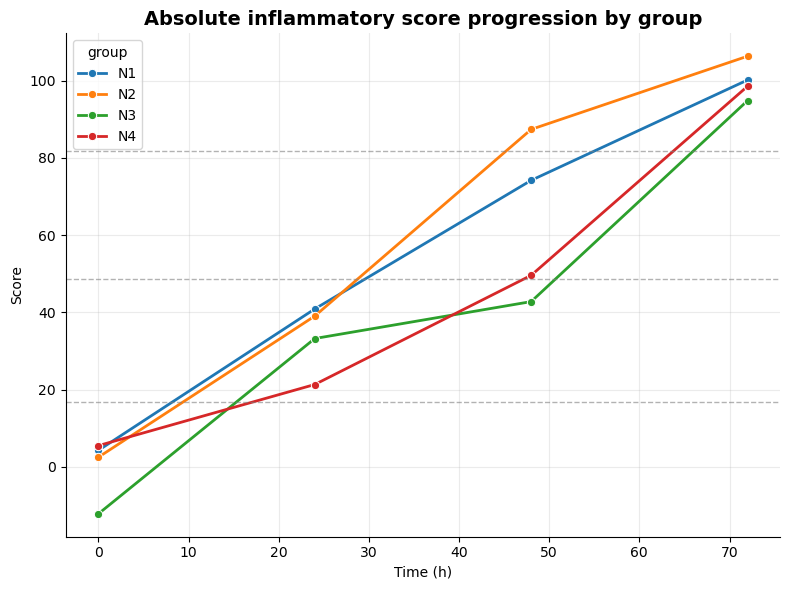

In [67]:
plt.figure(figsize=(8, 6))

sns.lineplot(
    data=df_temporal_group_scored,
    x="time_h",
    y="absolute_inflammatory_score",
    hue="group",
    marker="o",
    linewidth=2
)

for thr in thresholds_group:
    plt.axhline(thr, color="gray", linestyle="--", linewidth=1, alpha=0.6)

plt.title("Absolute inflammatory score progression by group", fontsize=14, fontweight="bold")
plt.xlabel("Time (h)")
plt.ylabel("Score")
plt.grid(True, alpha=0.25)
sns.despine()
plt.tight_layout()
plt.show()

# Save temporal absolut score model

In [68]:
import temporal.pipeline_temp as pip
importlib.reload(pip)

from temporal.pipeline_temp import save_temporal_score_model

In [100]:
temporal_metadata = pipeline_temp.save_temporal_score_model(df_temporal)
print(temporal_metadata)

Temporal score metadata guardada en: temporal_score_metadata.joblib
{'features': ['median_thickness', 'median_segment_length'], 'weights': {'median_thickness': 0.49739963249126556, 'median_segment_length': 0.5026003675087344}, 'rho_group_level': {'median_thickness': {'rho': -0.9458889376416987, 'p_value': 3.154794598281738e-08}, 'median_segment_length': {'rho': 0.9557790087219502, 'p_value': 7.886241272347204e-09}}, 'population_anchors': {'ctrl_ref': {'median_thickness': 14.638995137031191, 'median_segment_length': 13.6875}, 'inflam_ref': {'median_thickness': 10.247410236086402, 'median_segment_length': 15.8125}}, 'thresholds': [16.8093143775826, 48.558338740924356, 81.74902436334176], 'recovery_thresholds': [18.25097563665824, 51.441661259075644, 83.1906856224174], 'means_by_time': {'0HS': -4.6629367034256575e-15, '24HS': 33.618628755165204, '48HS': 63.49804872668351, '72HS': 100.0}, 'task': 'temporal_absolute_inflammatory_score', 'calibration_level': 'group_time', 'warning': 'Score c

In [70]:
print("Calibration level:", temporal_metadata["calibration_level"])

print("\nGroup-level rho:")
print(temporal_metadata["rho_group_level"])

print("\nWeights:")
print(temporal_metadata["weights"])

print("\nAnchors:")
print(temporal_metadata["population_anchors"])

print("\nThresholds:")
print(temporal_metadata["thresholds"])

Calibration level: group_time

Group-level rho:
{'median_thickness': {'rho': -0.9458889376416987, 'p_value': 3.154794598281738e-08}, 'median_segment_length': {'rho': 0.9557790087219502, 'p_value': 7.886241272347204e-09}}

Weights:
{'median_thickness': 0.49739963249126556, 'median_segment_length': 0.5026003675087344}

Anchors:
{'ctrl_ref': {'median_thickness': 14.638995137031191, 'median_segment_length': 13.6875}, 'inflam_ref': {'median_thickness': 10.247410236086402, 'median_segment_length': 15.8125}}

Thresholds:
[16.8093143775826, 48.558338740924356, 81.74902436334176]


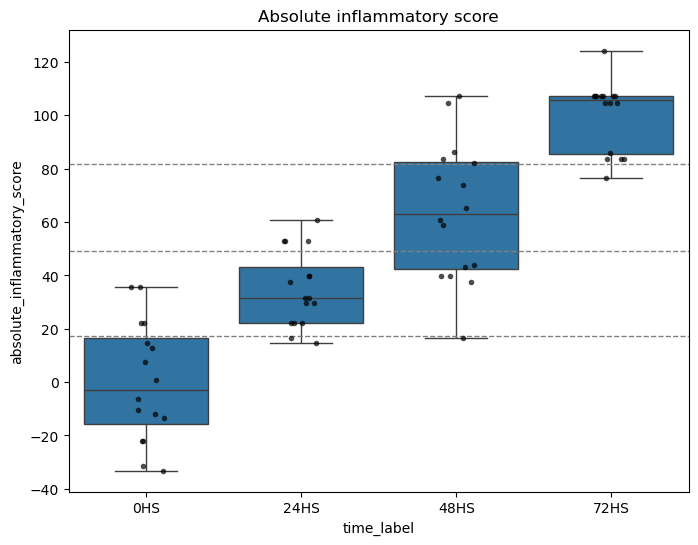

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.boxplot(
    data=df_temporal_abs,
    x="time_label",
    y="absolute_inflammatory_score",
    order=["0HS","24HS","48HS","72HS"],
    fliersize=0
)
sns.stripplot(
    data=df_temporal_abs,
    x="time_label",
    y="absolute_inflammatory_score",
    order=["0HS","24HS","48HS","72HS"],
    color="black",
    alpha=0.7,
    jitter=0.12,
    size=4
)

for thr in temporal_metadata["thresholds"]:
    plt.axhline(thr, color="gray", linestyle="--", linewidth=1)

plt.title("Absolute inflammatory score")
plt.show()

# Probamos con imagen conocida

In [74]:
new_img = temporal_dataset["48HS"]["N3"][0]["image"]

result_abs = pipeline_temp.predict_temporal_progression_score(new_img)

print("Score absoluto:", result_abs["score"])
print("Category:", result_abs["category"])
print("Warning:", result_abs["warning"])
print("Score features:", result_abs["score_features"])
#DA MALLLL

Score absoluto: 37.28096519738999
Category: mild inflammatory morphology
Score features: {'median_thickness': 12.0, 'median_segment_length': 14.0}


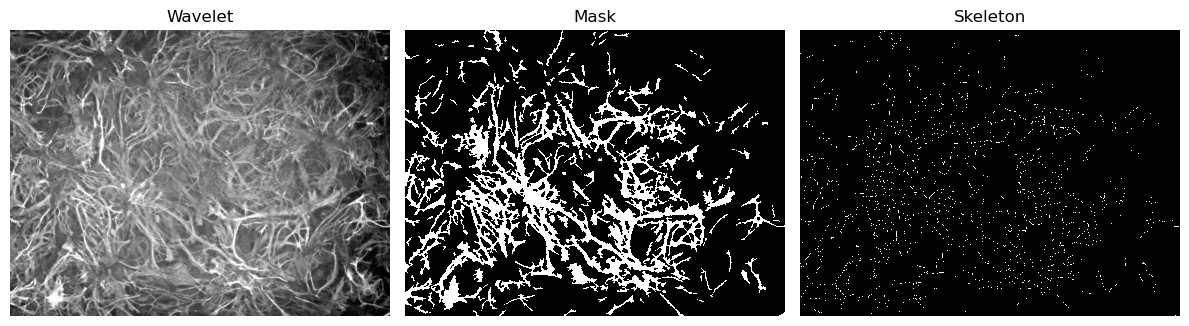

In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(result_abs["wavelet"], cmap="gray")
axes[0].set_title("Wavelet")

axes[1].imshow(result_abs["mask"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[1].set_title("Mask")

axes[2].imshow(result_abs["skeleton"], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[2].set_title("Skeleton")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [75]:
import importlib
from temporal import pipeline_temp

importlib.reload(pipeline_temp)

from temporal.pipeline_temp import test_temporal_progression_all_groups

“El siguiente test compara imágenes del mismo índice dentro de cada grupo, pero no representa una trayectoria longitudinal real de la misma muestra; por lo tanto, se usa solo como exploración cualitativa.”

In [76]:
df_all_progression = test_temporal_progression_all_groups(
    temporal_dataset,
    image_idx=0
)

  time_label group  image_idx   image_name       score  \
0        0HS    N1          0   Image2.tif  -33.085899   
1       24HS    N1          0  Image14.tif   37.280965   
2       48HS    N1          0  Image26.tif  112.065656   
3       72HS    N1          0  Image38.tif  107.236927   

                       category  median_thickness  median_segment_length  
0   low inflammatory morphology         16.124515                   13.0  
1  mild inflammatory morphology         12.000000                   14.0  
2  high inflammatory morphology         11.661904                   17.0  
3  high inflammatory morphology         10.000000                   16.0  

¿El score sube progresivamente?
False
  time_label group  image_idx    image_name       score  \
0        0HS    N2          0   Image98.tif   -2.413334   
1       24HS    N2          0  Image110.tif   37.280965   
2       48HS    N2          0  Image122.tif   88.413874   
3       72HS    N2          0  Image134.tif  107.236927   


In [77]:
df_all_progression_1 = pipeline_temp.test_temporal_progression_all_groups(
    temporal_dataset,
    image_idx=1
)

df_all_progression_2 = pipeline_temp.test_temporal_progression_all_groups(
    temporal_dataset,
    image_idx=2
)

df_all_progression_3 = pipeline_temp.test_temporal_progression_all_groups(
    temporal_dataset,
    image_idx=3
)

  time_label group  image_idx   image_name       score  \
0        0HS    N1          1   Image5.tif   -9.434117   
1       24HS    N1          1  Image17.tif   35.406195   
2       48HS    N1          1  Image29.tif   64.762092   
3       72HS    N1          1  Image41.tif  107.236927   

                           category  median_thickness  median_segment_length  
0       low inflammatory morphology         16.124515                   14.0  
1      mild inflammatory morphology         12.165525                   14.0  
2  moderate inflammatory morphology         11.661904                   15.0  
3      high inflammatory morphology         10.000000                   16.0  

¿El score sube progresivamente?
True
  time_label group  image_idx    image_name      score  \
0        0HS    N2          1  Image101.tif   8.283407   
1       24HS    N2          1  Image113.tif  11.754413   
2       48HS    N2          1  Image125.tif  74.860238   
3       72HS    N2          1  Image137.tif 

### Porcentaje global de pares bien ordenados

In [85]:
import importlib
from temporal import pipeline_temp

importlib.reload(pipeline_temp)

from temporal.pipeline_temp import temporal_pairwise_order_accuracy, temporal_pairwise_order_by_timepair

Group-level

In [80]:
pairwise_group_results = temporal_pairwise_order_accuracy(
    df_temporal_group_scored,
    score_col="absolute_inflammatory_score",
    time_col="time_h"
)

print(pairwise_group_results)

{'total_pairs': 96, 'correct_pairs': 96, 'ties': 0, 'pairwise_order_accuracy': 1.0, 'tie_rate': 0.0}


Imágenes individuales

In [81]:
anchors = temporal_metadata["population_anchors"]
weights = temporal_metadata["weights"]

ctrl_t = anchors["ctrl_ref"]["median_thickness"]
ctrl_s = anchors["ctrl_ref"]["median_segment_length"]
inflam_t = anchors["inflam_ref"]["median_thickness"]
inflam_s = anchors["inflam_ref"]["median_segment_length"]

w_t = weights["median_thickness"]
w_s = weights["median_segment_length"]

df_temporal_abs = df_temporal.copy()

df_temporal_abs["absolute_inflammatory_score"] = df_temporal_abs.apply(
    lambda row: pipeline_temp._compute_absolute_inflammatory_score(
        thickness=row["median_thickness"],
        segment_length=row["median_segment_length"],
        ctrl_thickness=ctrl_t,
        inflam_thickness=inflam_t,
        ctrl_segment=ctrl_s,
        inflam_segment=inflam_s,
        w_thickness=w_t,
        w_segment=w_s
    ),
    axis=1
)

print(df_temporal_abs.head())

   mask_area  fill_ratio  n_components  largest_component_area  \
0     621371    0.198303           175                105392.0   
1     626930    0.200077           177                175268.0   
2     615747    0.196508           215                126299.0   
3     611678    0.195210           238                 72312.0   
4     622016    0.198509           199                136781.0   

   largest_component_ratio  mean_component_area  std_component_area  \
0                 0.169612          3550.691429        12278.464942   
1                 0.279566          3541.977401        13970.684168   
2                 0.205115          2863.939535        10678.551265   
3                 0.118219          2570.075630         7194.847730   
4                 0.219899          3125.708543        12824.703776   

   median_component_area  skeleton_length  n_endpoints  ...  \
0                  587.0            33655          928  ...   
1                  606.0            34557         

In [83]:
pairwise_results = temporal_pairwise_order_accuracy(
    df_temporal_abs,
    score_col="absolute_inflammatory_score",
    time_col="time_h"
)

print(pairwise_results)

{'total_pairs': 1536, 'correct_pairs': 1403, 'ties': 21, 'pairwise_order_accuracy': 0.9134114583333334, 'tie_rate': 0.013671875}


### Porcentaje de pares de tiempos (imágenes individuales)

In [86]:
pairwise_time_results = temporal_pairwise_order_by_timepair(
    df_temporal_abs,
    score_col="absolute_inflammatory_score"
)

print(pairwise_time_results)

      time_pair  total_pairs  correct_pairs  ties  pairwise_order_accuracy  \
0   0HS vs 24HS          256            219     7                 0.855469   
1   0HS vs 48HS          256            244     0                 0.953125   
2   0HS vs 72HS          256            256     0                 1.000000   
3  24HS vs 48HS          256            211     7                 0.824219   
4  24HS vs 72HS          256            256     0                 1.000000   
5  48HS vs 72HS          256            217     7                 0.847656   

   tie_rate  
0  0.027344  
1  0.000000  
2  0.000000  
3  0.027344  
4  0.000000  
5  0.027344  


# Score relativo

In [97]:
import importlib
import temporal.pipeline_temp as pipeline_temp

importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

## Imagen 48hs

In [101]:
img_ctrl = temporal_dataset["0HS"]["N2"][0]["image"]
img_inflam = temporal_dataset["72HS"]["N2"][0]["image"]
img_new = temporal_dataset["48HS"]["N2"][0]["image"]

result_rel = pipeline_temp.predict_temporal_progression_score_anchored(
    img_new=img_new,
    img_ctrl=img_ctrl,
    img_inflam=img_inflam
)

print("Inflammatory score:", result_rel["inflammatory_score"])
print("Recovery score:", result_rel["recovery_score"])
print("Recovery category:", result_rel["recovery_category"])
print("Score features:", result_rel["score_features"])
print("Reference features:", result_rel["reference_features"])
print("Note:", result_rel["note"])

Inflammatory score: 75.80410867517271
Recovery score: 24.195891324827286
Recovery category: partial recovery
Score features: {'median_thickness': 11.661903789690601, 'median_segment_length': 16.0}
Reference features: {'control': {'median_thickness': 13.416407864998739, 'median_segment_length': 13.0}, 'inflamed': {'median_thickness': 10.0, 'median_segment_length': 16.0}}
Note: Score calculado usando referencias control e inflamada del mismo experimento.


## Imagen 24hs

In [109]:
img_new_24 = temporal_dataset["24HS"]["N2"][0]["image"]

result_rel_24 = pipeline_temp.predict_temporal_progression_score_anchored(
    img_new=img_new_24,
    img_ctrl=img_ctrl,
    img_inflam=img_inflam
)

print("Inflammatory score:", result_rel_24["inflammatory_score"])
print("Recovery score:", result_rel_24["recovery_score"])
print("Recovery category:", result_rel_24["recovery_category"])

Inflammatory score: 37.37502716696116
Recovery score: 62.62497283303884
Recovery category: substantial recovery


## Score relativo de 4 tiempos distintos de un mismo grupo 

In [104]:
import importlib
import temporal.pipeline_temp as pipeline_temp

importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [105]:
df_test_rel = pipeline_temp.test_temporal_progression_anchored_on_four_images(
    temporal_dataset,
    group="N2",
    image_idx=0
)

  time_label group  image_idx    image_name  inflammatory_score  \
0        0HS    N2          0   Image98.tif            0.000000   
1       24HS    N2          0  Image110.tif           37.375027   
2       48HS    N2          0  Image122.tif           75.804109   
3       72HS    N2          0  Image134.tif          100.000000   

   recovery_score       recovery_category  
0      100.000000  near-complete recovery  
1       62.624973    substantial recovery  
2       24.195891        partial recovery  
3        0.000000        minimal recovery  

¿El inflammatory score sube progresivamente?
True


In [110]:
df_test_rel = pipeline_temp.test_temporal_progression_anchored_on_four_images(
    temporal_dataset,
    group="N1",
    image_idx=0
)

  time_label group  image_idx   image_name  inflammatory_score  \
0        0HS    N1          0   Image2.tif            0.000000   
1       24HS    N1          0  Image14.tif           50.250403   
2       48HS    N1          0  Image26.tif          103.256272   
3       72HS    N1          0  Image38.tif          100.000000   

   recovery_score       recovery_category  
0      100.000000  near-complete recovery  
1       49.749597        partial recovery  
2       -3.256272        minimal recovery  
3        0.000000        minimal recovery  

¿El inflammatory score sube progresivamente?
False


In [111]:
df_test_rel = pipeline_temp.test_temporal_progression_anchored_on_four_images(
    temporal_dataset,
    group="N3",
    image_idx=0
)

  time_label group  image_idx   image_name  inflammatory_score  \
0        0HS    N3          0   Image2.tif            0.000000   
1       24HS    N3          0  Image14.tif           49.096254   
2       48HS    N3          0  Image26.tif           57.063417   
3       72HS    N3          0  Image39.tif          100.000000   

   recovery_score       recovery_category  
0      100.000000  near-complete recovery  
1       50.903746        partial recovery  
2       42.936583        partial recovery  
3        0.000000        minimal recovery  

¿El inflammatory score sube progresivamente?
True


In [112]:
df_test_rel = pipeline_temp.test_temporal_progression_anchored_on_four_images(
    temporal_dataset,
    group="N4",
    image_idx=0
)

  time_label group  image_idx    image_name  inflammatory_score  \
0        0HS    N4          0  Image101.tif            0.000000   
1       24HS    N4          0  Image113.tif           21.417963   
2       48HS    N4          0  Image125.tif           58.289994   
3       72HS    N4          0  Image137.tif          100.000000   

   recovery_score       recovery_category  
0      100.000000  near-complete recovery  
1       78.582037    substantial recovery  
2       41.710006        partial recovery  
3        0.000000        minimal recovery  

¿El inflammatory score sube progresivamente?
True


## Validación score relativo

### Monoticidad en todas las trayectorias ancladas

Para cada trayectoria:
0HS
24HS
48HS
72HS

usando como referencias:
0HS del mismo group e image_idx
72HS del mismo group e image_idx

medir si:
0HS≤24HS≤48HS≤72HS
para el inflammatory score.

In [116]:
importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [114]:
df_monotonic_rel, summary_monotonic_rel = pipeline_temp.validate_anchored_monotonicity_all(temporal_dataset)

print(summary_monotonic_rel)
print(df_monotonic_rel)

{'total_trajectories': 16, 'monotonic_trajectories': 9, 'monotonicity_rate': 0.5625}
   group  image_idx  0HS_score  24HS_score  48HS_score  72HS_score  monotonic
0     N1          0        0.0   50.250403  103.256272       100.0      False
1     N1          1        0.0   32.152754   61.372909       100.0       True
2     N1          2        0.0   11.858596  122.410689       100.0      False
3     N1          3        0.0   26.165425  -26.260128       100.0      False
4     N2          0        0.0   37.375027   75.804109       100.0       True
5     N2          1        0.0  -22.954422   93.474431       100.0      False
6     N2          2        0.0   43.958920   74.869982       100.0       True
7     N2          3        0.0   53.700608  124.710722       100.0      False
8     N3          0        0.0   49.096254   57.063417       100.0       True
9     N3          1        0.0   61.285543   31.787774       100.0      False
10    N3          2        0.0   37.598503   71.105194   

### Exactitud por pares temporales en el modo relativo

Sobre todas las imágenes evaluadas con el modo relativo:

porcentaje de pares correctamente ordenados:
- 0HS < 24HS
- 0HS < 48HS
- 0HS < 72HS
- 24HS < 48HS
- 24HS < 72HS
- 48HS < 72HS

Qué reportar
- accuracy global de orden temporal
- accuracy por cada par de tiempos

In [117]:
df_relative_scores = pipeline_temp.build_anchored_relative_scores_dataframe(temporal_dataset)

pairwise_rel_global = temporal_pairwise_order_accuracy(
    df_relative_scores,
    score_col="relative_inflammatory_score"
)

pairwise_rel_by_time = temporal_pairwise_order_by_timepair(
    df_relative_scores,
    score_col="relative_inflammatory_score"
)

print(pairwise_rel_global)
print(pairwise_rel_by_time)

{'total_pairs': 1536, 'correct_pairs': 1360, 'ties': 33, 'pairwise_order_accuracy': 0.8854166666666666, 'tie_rate': 0.021484375}
      time_pair  total_pairs  correct_pairs  ties  pairwise_order_accuracy  \
0   0HS vs 24HS          256            192    32                   0.7500   
1   0HS vs 48HS          256            240     0                   0.9375   
2   0HS vs 72HS          256            256     0                   1.0000   
3  24HS vs 48HS          256            208     1                   0.8125   
4  24HS vs 72HS          256            256     0                   1.0000   
5  48HS vs 72HS          256            208     0                   0.8125   

   tie_rate  
0  0.125000  
1  0.000000  
2  0.000000  
3  0.003906  
4  0.000000  
5  0.000000  


### Validación leave-one-group-out

Que dentro de cada grupo:
el score relativo mantenga la progresión esperada
y no dependa de un único cultivo

Reportar:
- monotonicidad por grupo
- medias por tiempo dentro de cada grupo

### Sensibilidad a la elección de la referencia dentro del mismo tiempo

Para una imagen nueva fija, calcular el score relativo usando distintas referencias posibles del mismo grupo:

- control idx 0, 1, 2, 3
- inflamada idx 0, 1, 2, 3

y ver cuánto cambia el score.

In [118]:
importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [119]:
df_sensitivity_all = pipeline_temp.anchored_reference_sensitivity_all(temporal_dataset)
print(df_sensitivity_all)

   group target_time  target_idx  n_reference_combinations  inflam_mean  \
0     N1        24HS           0                        16    25.580574   
1     N1        24HS           1                        16    23.748202   
2     N1        24HS           2                        16    18.394883   
3     N1        24HS           3                        16    55.422471   
4     N1        48HS           0                        16   118.849008   
5     N1        48HS           1                        16    59.165215   
6     N1        48HS           2                        16    85.264368   
7     N1        48HS           3                        16    23.748202   
8     N2        24HS           0                        16    40.250356   
9     N2        24HS           1                        16    14.863185   
10    N2        24HS           2                        16    52.519468   
11    N2        24HS           3                        16    52.519468   
12    N2        48HS     

### Visualización por grupo y tiempo

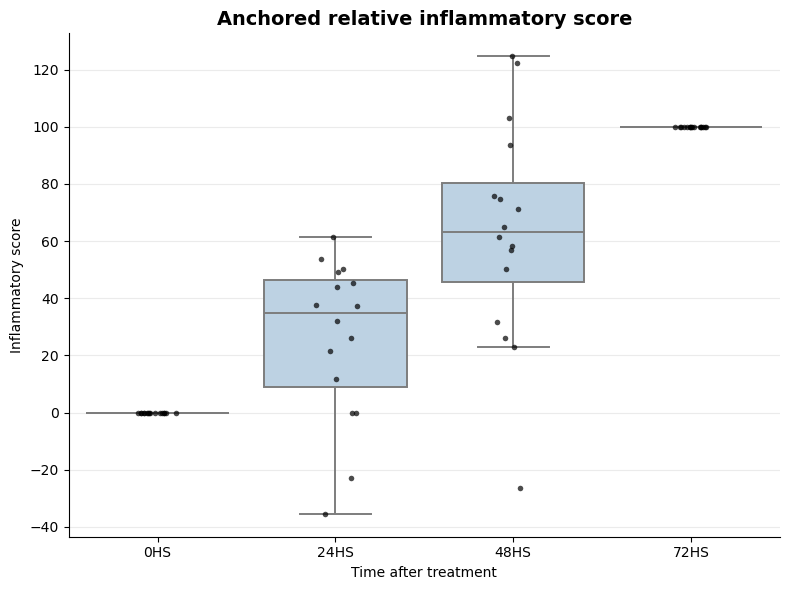

In [122]:
pipeline_temp.plot_relative_inflammatory_score(df_relative_scores)

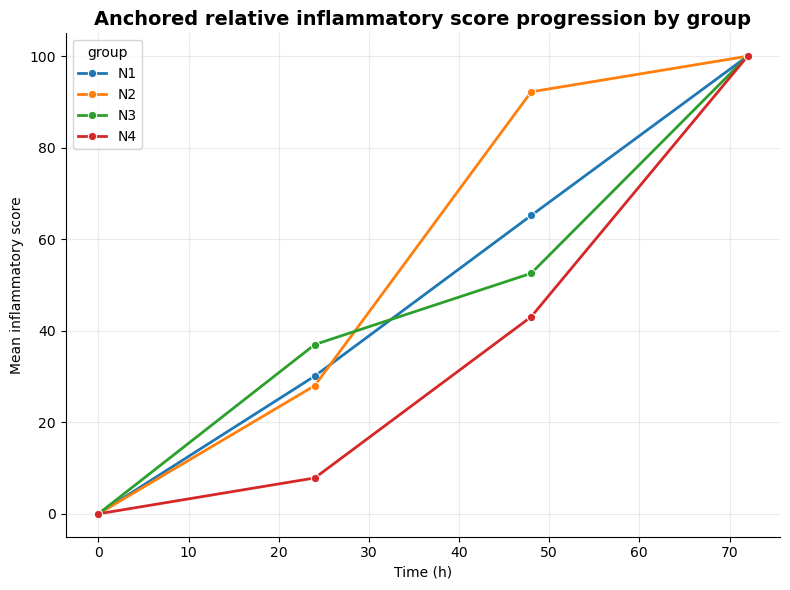

   group time_label  time_h  relative_inflammatory_score
0     N1        0HS       0                     0.000000
1     N1       24HS      24                    30.106795
2     N1       48HS      48                    65.194936
3     N1       72HS      72                   100.000000
4     N2        0HS       0                     0.000000
5     N2       24HS      24                    28.020033
6     N2       48HS      48                    92.214811
7     N2       72HS      72                   100.000000
8     N3        0HS       0                     0.000000
9     N3       24HS      24                    36.995075
10    N3       48HS      48                    52.554105
11    N3       72HS      72                   100.000000
12    N4        0HS       0                     0.000000
13    N4       24HS      24                     7.842492
14    N4       48HS      48                    43.049137
15    N4       72HS      72                   100.000000


In [121]:
df_group_relative = pipeline_temp.plot_relative_score_by_group(df_relative_scores)
print(df_group_relative)

### Comparación relative vs absolute

## Prueba de score relativo con varias imagenes de referencia en vez de 1

In [129]:
import importlib
import temporal.pipeline_temp as pipeline_temp

importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [124]:
ctrl_images_N2 = [item["image"] for item in temporal_dataset["0HS"]["N2"]]
inflam_images_N2 = [item["image"] for item in temporal_dataset["72HS"]["N2"]]

img_new_24 = temporal_dataset["24HS"]["N2"][0]["image"]
img_new_48 = temporal_dataset["48HS"]["N2"][0]["image"]

result_rel_24 = pipeline_temp.predict_temporal_progression_score_anchored(
    img_new=img_new_24,
    ctrl_images=ctrl_images_N2,
    inflam_images=inflam_images_N2
)

result_rel_48 = pipeline_temp.predict_temporal_progression_score_anchored(
    img_new=img_new_48,
    ctrl_images=ctrl_images_N2,
    inflam_images=inflam_images_N2
)

print("24HS")
print("Inflammatory score:", result_rel_24["inflammatory_score"])
print("Recovery score:", result_rel_24["recovery_score"])
print("Recovery category:", result_rel_24["recovery_category"])
print("Note:", result_rel_24["note"])

print("\n48HS")
print("Inflammatory score:", result_rel_48["inflammatory_score"])
print("Recovery score:", result_rel_48["recovery_score"])
print("Recovery category:", result_rel_48["recovery_category"])
print("Note:", result_rel_48["note"])

24HS
Inflammatory score: 38.565882881955574
Recovery score: 61.434117118044426
Recovery category: substantial recovery
Note: Score calculado usando 4 imágenes control y 4 imágenes inflamadas del mismo experimento.

48HS
Inflammatory score: 80.02056177980428
Recovery score: 19.979438220195718
Recovery category: partial recovery
Note: Score calculado usando 4 imágenes control y 4 imágenes inflamadas del mismo experimento.


In [132]:
df_test_rel_multi = pipeline_temp.test_temporal_progression_anchored_on_four_images_multi_ref(
    temporal_dataset,
    group="N2",
    image_idx=0
)

  time_label group  image_idx    image_name  inflammatory_score  \
0        0HS    N2          0   Image98.tif           -0.246439   
1       24HS    N2          0  Image110.tif           38.565883   
2       48HS    N2          0  Image122.tif           80.020562   
3       72HS    N2          0  Image134.tif          104.115856   

   recovery_score       recovery_category  
0      100.246439  near-complete recovery  
1       61.434117    substantial recovery  
2       19.979438        partial recovery  
3       -4.115856        minimal recovery  

¿El inflammatory score sube progresivamente?
True


In [133]:
df_test_rel_multi = pipeline_temp.test_temporal_progression_anchored_on_four_images_multi_ref(
    temporal_dataset,
    group="N1",
    image_idx=0
)

  time_label group  image_idx   image_name  inflammatory_score  \
0        0HS    N1          0   Image2.tif          -41.194462   
1       24HS    N1          0  Image14.tif           30.111974   
2       48HS    N1          0  Image26.tif          119.762946   
3       72HS    N1          0  Image38.tif          108.202401   

   recovery_score       recovery_category  
0      141.194462  near-complete recovery  
1       69.888026    substantial recovery  
2      -19.762946        minimal recovery  
3       -8.202401        minimal recovery  

¿El inflammatory score sube progresivamente?
False


In [134]:
df_test_rel_multi = pipeline_temp.test_temporal_progression_anchored_on_four_images_multi_ref(
    temporal_dataset,
    group="N3",
    image_idx=0
)

  time_label group  image_idx   image_name  inflammatory_score  \
0        0HS    N3          0   Image2.tif          -10.079619   
1       24HS    N3          0  Image14.tif           37.641313   
2       48HS    N3          0  Image26.tif           46.079500   
3       72HS    N3          0  Image39.tif           87.276597   

   recovery_score       recovery_category  
0      110.079619  near-complete recovery  
1       62.358687    substantial recovery  
2       53.920500    substantial recovery  
3       12.723403        minimal recovery  

¿El inflammatory score sube progresivamente?
True


In [135]:
df_test_rel_multi = pipeline_temp.test_temporal_progression_anchored_on_four_images_multi_ref(
    temporal_dataset,
    group="N4",
    image_idx=0
)

  time_label group  image_idx    image_name  inflammatory_score  \
0        0HS    N4          0  Image101.tif          -12.986936   
1       24HS    N4          0  Image113.tif           15.158830   
2       48HS    N4          0  Image125.tif           59.309260   
3       72HS    N4          0  Image137.tif          109.817368   

   recovery_score       recovery_category  
0      112.986936  near-complete recovery  
1       84.841170  near-complete recovery  
2       40.690740        partial recovery  
3       -9.817368        minimal recovery  

¿El inflammatory score sube progresivamente?
True


In [139]:
importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

### Monoticidad en todas las trayectorias ancladas

In [137]:
df_monotonic_rel_multi, summary_monotonic_rel_multi = pipeline_temp.validate_anchored_monotonicity_all_multi_ref(temporal_dataset)

print(summary_monotonic_rel_multi)
print(df_monotonic_rel_multi)

{'total_trajectories': 16, 'monotonic_trajectories': 11, 'monotonicity_rate': 0.6875}
   group  image_idx  0HS_score  24HS_score  48HS_score  72HS_score  monotonic
0     N1          0 -41.194462   30.111974  119.762946  108.202401      False
1     N1          1 -12.474441   28.402896   62.322904  108.202401       True
2     N1          2  15.487291   23.409782   87.552016   77.437589      False
3     N1          3  38.181611   58.831995   28.402896  106.157610      False
4     N2          0  -0.246439   38.565883   80.020562  104.115856       True
5     N2          1   1.446256   17.889623   74.670771   82.968188       True
6     N2          2   7.507895   47.431058   82.968188  101.244565       True
7     N2          3  -8.707713   47.431058  101.244565  111.671391       True
8     N3          0 -10.079619   37.641313   46.079500   87.276597       True
9     N3          1 -18.122248   61.623710   22.009323  111.687066      False
10    N3          2  -3.053525   39.285916   83.961504  

### Exactitud por pares temporales en el modo relativo

In [140]:
df_relative_scores_multi = pipeline_temp.build_anchored_relative_scores_dataframe_multi_ref(temporal_dataset)
print(df_relative_scores_multi.head())

  group  image_idx time_label  time_h   image_name  \
0    N1          0        0HS       0   Image2.tif   
1    N1          0       24HS      24  Image14.tif   
2    N1          0       48HS      48  Image26.tif   
3    N1          0       72HS      72  Image38.tif   
4    N1          1        0HS       0   Image5.tif   

   relative_inflammatory_score  relative_recovery_score  \
0                   -41.194462               141.194462   
1                    30.111974                69.888026   
2                   119.762946               -19.762946   
3                   108.202401                -8.202401   
4                   -12.474441               112.474441   

        recovery_category  
0  near-complete recovery  
1    substantial recovery  
2        minimal recovery  
3        minimal recovery  
4  near-complete recovery  


In [141]:
pairwise_rel_multi_global = temporal_pairwise_order_accuracy(
    df_relative_scores_multi,
    score_col="relative_inflammatory_score"
)

pairwise_rel_multi_by_time = temporal_pairwise_order_by_timepair(
    df_relative_scores_multi,
    score_col="relative_inflammatory_score"
)

print(pairwise_rel_multi_global)
print(pairwise_rel_multi_by_time)

{'total_pairs': 1536, 'correct_pairs': 1413, 'ties': 5, 'pairwise_order_accuracy': 0.919921875, 'tie_rate': 0.0032552083333333335}
      time_pair  total_pairs  correct_pairs  ties  pairwise_order_accuracy  \
0   0HS vs 24HS          256            224     2                 0.875000   
1   0HS vs 48HS          256            245     0                 0.957031   
2   0HS vs 72HS          256            256     0                 1.000000   
3  24HS vs 48HS          256            211     1                 0.824219   
4  24HS vs 72HS          256            256     0                 1.000000   
5  48HS vs 72HS          256            221     2                 0.863281   

   tie_rate  
0  0.007812  
1  0.000000  
2  0.000000  
3  0.003906  
4  0.000000  
5  0.007812  


### Visualización por grupo y tiempo

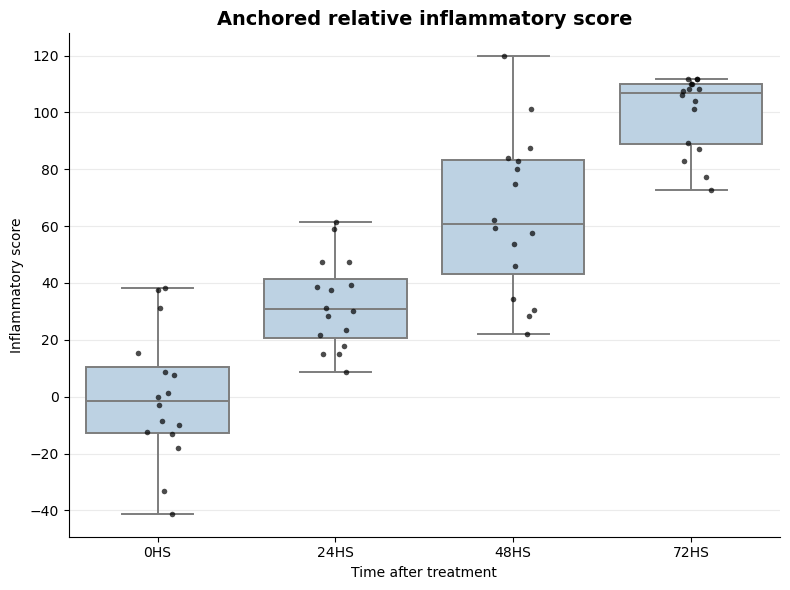

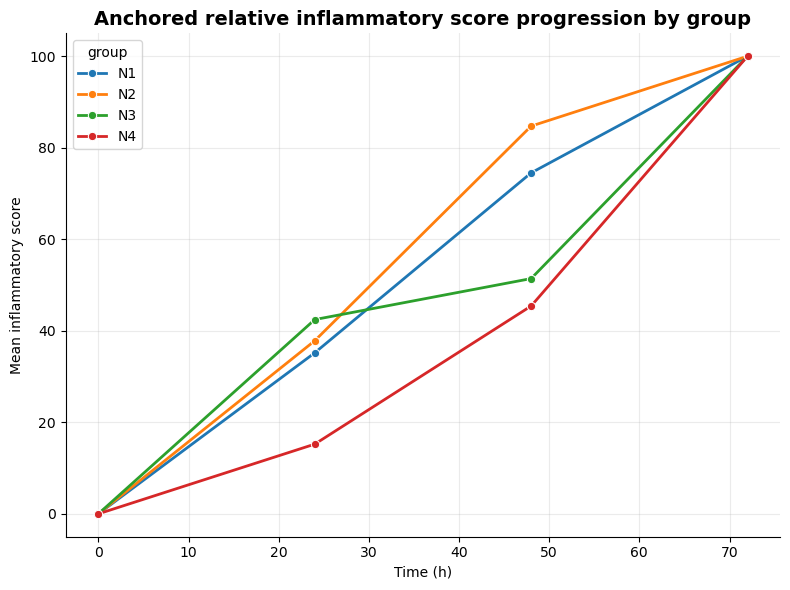

   group time_label  time_h  relative_inflammatory_score
0     N1        0HS       0                 0.000000e+00
1     N1       24HS      24                 3.518916e+01
2     N1       48HS      48                 7.451019e+01
3     N1       72HS      72                 1.000000e+02
4     N2        0HS       0                -6.661338e-15
5     N2       24HS      24                 3.782941e+01
6     N2       48HS      48                 8.472602e+01
7     N2       72HS      72                 1.000000e+02
8     N3        0HS       0                -4.440892e-15
9     N3       24HS      24                 4.245158e+01
10    N3       48HS      48                 5.141088e+01
11    N3       72HS      72                 1.000000e+02
12    N4        0HS       0                -8.881784e-16
13    N4       24HS      24                 1.523119e+01
14    N4       48HS      48                 4.541925e+01
15    N4       72HS      72                 1.000000e+02


In [142]:
pipeline_temp.plot_relative_inflammatory_score(df_relative_scores_multi)
df_group_relative_multi = pipeline_temp.plot_relative_score_by_group(df_relative_scores_multi)
print(df_group_relative_multi)

### Validación por grupo

In [143]:
importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [144]:
summary_group_relative = pipeline_temp.summarize_relative_score_by_group(df_relative_scores_multi)
print(summary_group_relative)

    index group time_label  time_h          mean        std      median  \
0       0    N1        0HS       0  0.000000e+00  34.401003    1.506425   
1       1    N1       24HS      24  3.518916e+01  16.016331   29.257435   
2       2    N1       48HS      48  7.451019e+01  38.696742   74.937460   
3       3    N1       72HS      72  1.000000e+02  15.072462  107.180005   
4       4    N2        0HS       0 -6.661338e-15   6.691914    0.599909   
5       5    N2       24HS      24  3.782941e+01  13.934619   42.998471   
6       6    N2       48HS      48  8.472602e+01  11.535477   81.494375   
7       7    N2       72HS      72  1.000000e+02  12.176387  102.680210   
8       8    N3        0HS       0 -4.440892e-15  21.727388   -6.566572   
9       9    N3       24HS      24  4.245158e+01  13.242423   38.463614   
10     10    N3       48HS      48  5.141088e+01  25.541997   49.836343   
11     11    N3       72HS      72  1.000000e+02  13.521563  100.518169   
12     12    N4        0H

In [146]:
df_group_monotonic, summary_group_monotonic = pipeline_temp.validate_groupwise_monotonicity(
    summary_group_relative
)

print(summary_group_monotonic)
print(df_group_monotonic)

{'total_groups': 4, 'monotonic_groups': 4, 'group_monotonicity_rate': 1.0}
  group      0HS_mean  24HS_mean  48HS_mean  72HS_mean  monotonic
0    N1  0.000000e+00  35.189162  74.510191      100.0       True
1    N2 -6.661338e-15  37.829406  84.726021      100.0       True
2    N3 -4.440892e-15  42.451583  51.410878      100.0       True
3    N4 -8.881784e-16  15.231186  45.419248      100.0       True


In [149]:
pivot_group_relative = (
    summary_group_relative
    .pivot(index="group", columns="time_label", values="mean")
    [["0HS", "24HS", "48HS", "72HS"]]
)

print(pivot_group_relative)

time_label           0HS       24HS       48HS   72HS
group                                                
N1          0.000000e+00  35.189162  74.510191  100.0
N2         -6.661338e-15  37.829406  84.726021  100.0
N3         -4.440892e-15  42.451583  51.410878  100.0
N4         -8.881784e-16  15.231186  45.419248  100.0


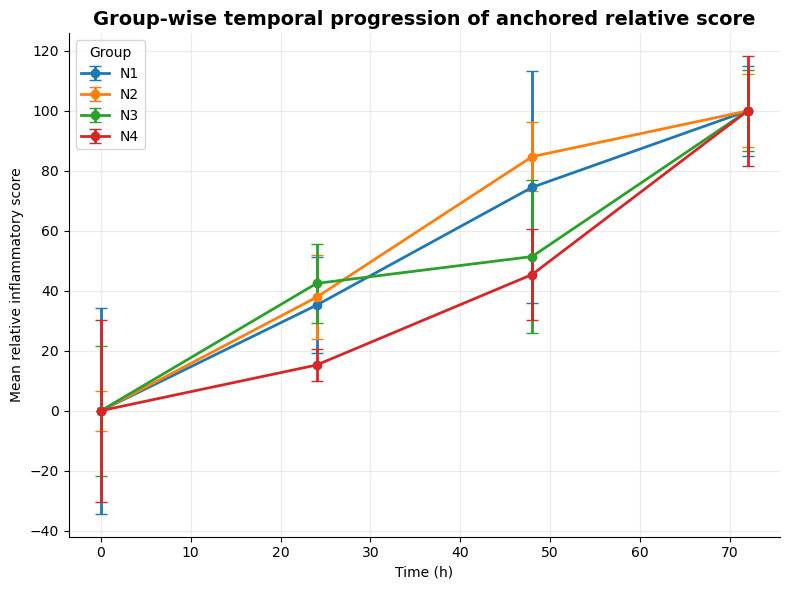

In [148]:
pipeline_temp.plot_groupwise_relative_summary(summary_group_relative)

### Análisis complementario de este score

Valida que:

- los pesos
- y los thresholds interpretativos

no dependan demasiado de un cultivo particular.

In [150]:
importlib.reload(pipeline_temp)

<module 'temporal.pipeline_temp' from '/Users/alexiagarciaguevara/Documents/ITBA/5 año - 1C/Proyecto Final/Proyecto Final Astrocitos/temporal/pipeline_temp.py'>

In [151]:
df_relative_scores_loo, metadata_loo = pipeline_temp.build_anchored_relative_scores_dataframe_multi_ref_loo(
    temporal_dataset,
    df_temporal
)

print(df_relative_scores_loo.head())

  held_out_group group  image_idx time_label  time_h   image_name  \
0             N1    N1          0        0HS       0   Image2.tif   
1             N1    N1          0       24HS      24  Image14.tif   
2             N1    N1          0       48HS      48  Image26.tif   
3             N1    N1          0       72HS      72  Image38.tif   
4             N1    N1          1        0HS       0   Image5.tif   

   relative_inflammatory_score  relative_recovery_score  \
0                   -41.167535               141.167535   
1                    30.162814                69.837186   
2                   119.675716               -19.675716   
3                   108.192130                -8.192130   
4                   -12.495502               112.495502   

        recovery_category  
0  near-complete recovery  
1    substantial recovery  
2        minimal recovery  
3        minimal recovery  
4  near-complete recovery  


In [152]:
df_monotonic_loo, summary_monotonic_loo = pipeline_temp.validate_anchored_monotonicity_all_multi_ref_loo(
    df_relative_scores_loo
)

print(summary_monotonic_loo)
print(df_monotonic_loo)

{'total_trajectories': 16, 'monotonic_trajectories': 11, 'monotonicity_rate': 0.6875}
   group  image_idx  0HS_score  24HS_score  48HS_score  72HS_score  monotonic
0     N1          0 -41.167535   30.162814  119.675716  108.192130      False
1     N1          1 -12.495502   28.450850   62.331649  108.192130       True
2     N1          2  15.513439   23.449306   87.506881   77.471853      False
3     N1          3  38.149598   58.834847   28.450850  106.143887      False
4     N2          0  -0.177524   38.644206   79.978724  104.166601       True
5     N2          1   1.381952   18.028223   74.748100   83.077400       True
6     N2          2   7.466882   47.403722   83.077400  101.284278       True
7     N2          3  -8.671310   47.403722  101.284278  111.471721       True
8     N3          0 -10.068999   37.685667   46.210731   87.374394       True
9     N3          1 -18.194432   61.457393   22.350319  111.578599      False
10    N3          2  -2.970566   39.347202   83.567585  

In [153]:
pairwise_loo_global = temporal_pairwise_order_accuracy(
    df_relative_scores_loo,
    score_col="relative_inflammatory_score"
)

pairwise_loo_by_time = temporal_pairwise_order_by_timepair(
    df_relative_scores_loo,
    score_col="relative_inflammatory_score"
)

print(pairwise_loo_global)
print(pairwise_loo_by_time)

{'total_pairs': 1536, 'correct_pairs': 1412, 'ties': 5, 'pairwise_order_accuracy': 0.9192708333333334, 'tie_rate': 0.0032552083333333335}
      time_pair  total_pairs  correct_pairs  ties  pairwise_order_accuracy  \
0   0HS vs 24HS          256            223     2                 0.871094   
1   0HS vs 48HS          256            245     0                 0.957031   
2   0HS vs 72HS          256            256     0                 1.000000   
3  24HS vs 48HS          256            211     1                 0.824219   
4  24HS vs 72HS          256            256     0                 1.000000   
5  48HS vs 72HS          256            221     2                 0.863281   

   tie_rate  
0  0.007812  
1  0.000000  
2  0.000000  
3  0.003906  
4  0.000000  
5  0.007812  


In [154]:
summary_group_relative_loo = pipeline_temp.summarize_relative_score_by_group(
    df_relative_scores_loo,
    score_col="relative_inflammatory_score"
)

df_group_monotonic_loo, summary_group_monotonic_loo = pipeline_temp.validate_groupwise_monotonicity(
    summary_group_relative_loo
)

print(summary_group_relative_loo)
print(summary_group_monotonic_loo)
print(df_group_monotonic_loo)

    index group time_label  time_h          mean        std      median  \
0       0    N1        0HS       0  0.000000e+00  34.384891    1.508969   
1       1    N1       24HS      24  3.522445e+01  15.995902   29.306832   
2       2    N1       48HS      48  7.449127e+01  38.637706   74.919265   
3       3    N1       72HS      72  1.000000e+02  15.049770  107.168008   
4       4    N2        0HS       0 -6.661338e-15   6.655505    0.602214   
5       5    N2       24HS      24  3.786997e+01  13.857359   43.023964   
6       6    N2       48HS      48  8.477213e+01  11.532289   81.528062   
7       7    N2       72HS      72  1.000000e+02  12.069034  102.725440   
8       8    N3        0HS       0 -4.440892e-15  21.731766   -6.519783   
9       9    N3       24HS      24  4.243106e+01  13.158071   38.516434   
10     10    N3       48HS      48  5.136821e+01  25.227906   49.777460   
11     11    N3       72HS      72  1.000000e+02  13.397118  100.523503   
12     12    N4        0H

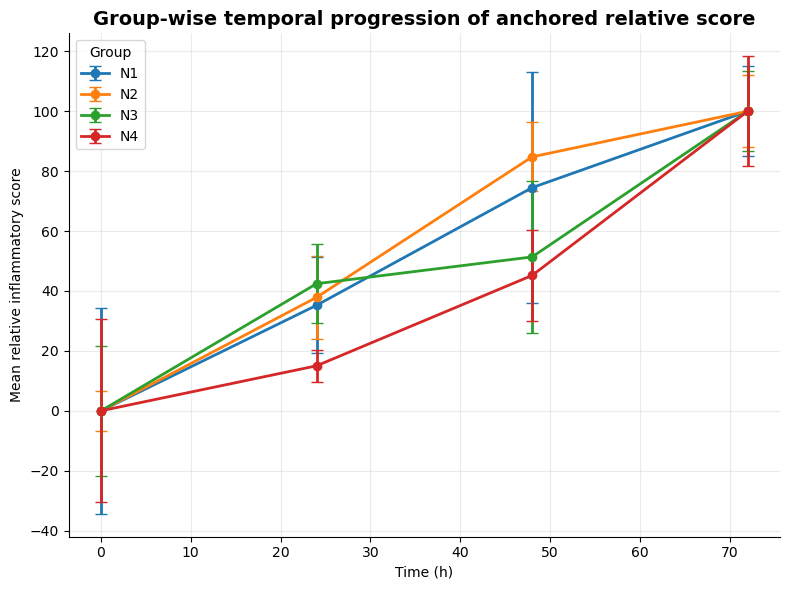

In [155]:
pipeline_temp.plot_groupwise_relative_summary(summary_group_relative_loo)

Se realizó además un análisis leave-one-group-out para evaluar si la calibración temporal (pesos y thresholds) dependía de forma crítica de algún cultivo particular. Los resultados fueron prácticamente idénticos a los obtenidos con la calibración completa, manteniéndose la monotonicidad por grupo (4/4 grupos) y una pairwise ordering accuracy global de ~0.92. Esto sugiere que la calibración del score es estable frente a la exclusión de un grupo.